In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test features: {X_test.shape}")
print("✅ Data loaded successfully!")

Training features: (125973, 41)
Training labels: (125973,)
Test features: (22544, 41)
✅ Data loaded successfully!


METHOD 3: MUTUAL INFORMATION
Top 15 features by Mutual Information:
                     feature  mutual_info
4                  src_bytes     0.565839
2                    service     0.468162
5                  dst_bytes     0.442150
3                       flag     0.365923
29             diff_srv_rate     0.363098
28             same_srv_rate     0.359521
32        dst_host_srv_count     0.335380
33    dst_host_same_srv_rate     0.309054
11                 logged_in     0.291465
37      dst_host_serror_rate     0.289086
34    dst_host_diff_srv_rate     0.286168
38  dst_host_srv_serror_rate     0.285908
24               serror_rate     0.280231
25           srv_serror_rate     0.270657
22                     count     0.266037


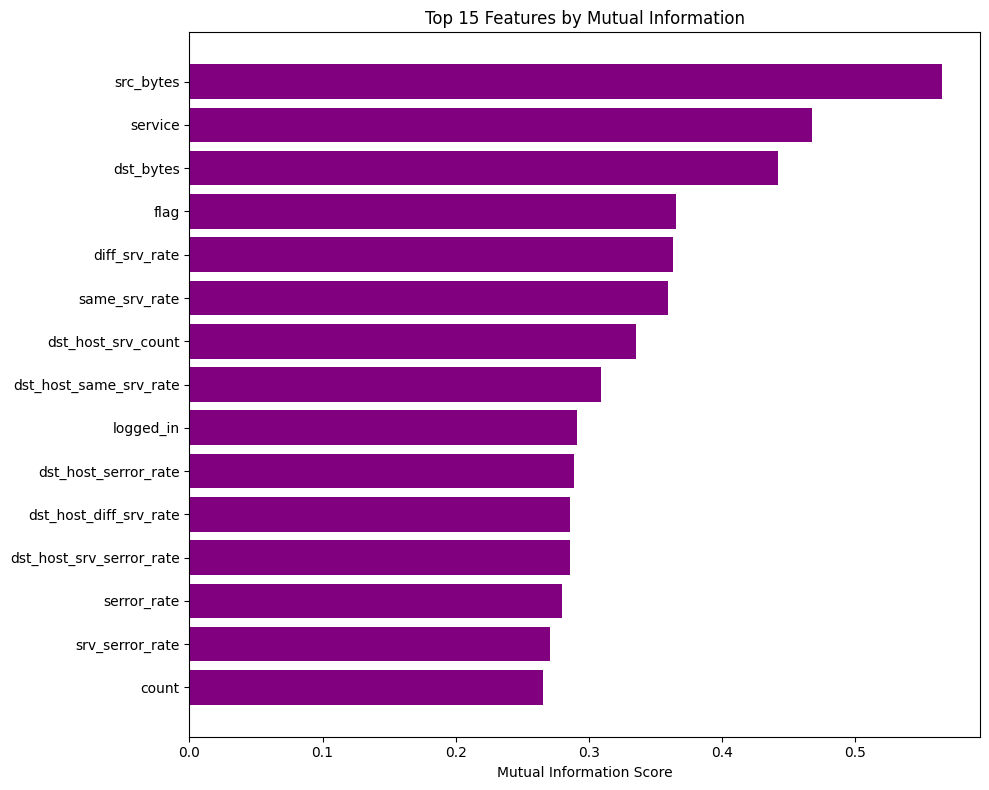

In [2]:
print("METHOD 3: MUTUAL INFORMATION")
print("=" * 60)

# Mutual Information measures how much information a feature provides about the target
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mutual_info': mi
}).sort_values('mutual_info', ascending=False)

print("Top 15 features by Mutual Information:")
print(mi_df.head(15))

# Visualize
plt.figure(figsize=(10, 8))
top_mi = mi_df.head(15)
plt.barh(top_mi['feature'], top_mi['mutual_info'], color='purple')
plt.xlabel('Mutual Information Score')
plt.title('Top 15 Features by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

METHOD 1: CORRELATION WITH TARGET
Top 15 features by correlation with attack:
                     feature  correlation
28             same_srv_rate     0.751913
32        dst_host_srv_count     0.722535
33    dst_host_same_srv_rate     0.693803
11                 logged_in     0.690171
38  dst_host_srv_serror_rate     0.654985
37      dst_host_serror_rate     0.651842
24               serror_rate     0.650652
25           srv_serror_rate     0.648289
3                       flag     0.647073
22                     count     0.576444
31            dst_host_count     0.375052
1              protocol_type     0.281355
2                    service     0.276548
27           srv_rerror_rate     0.253504
40  dst_host_srv_rerror_rate     0.253430


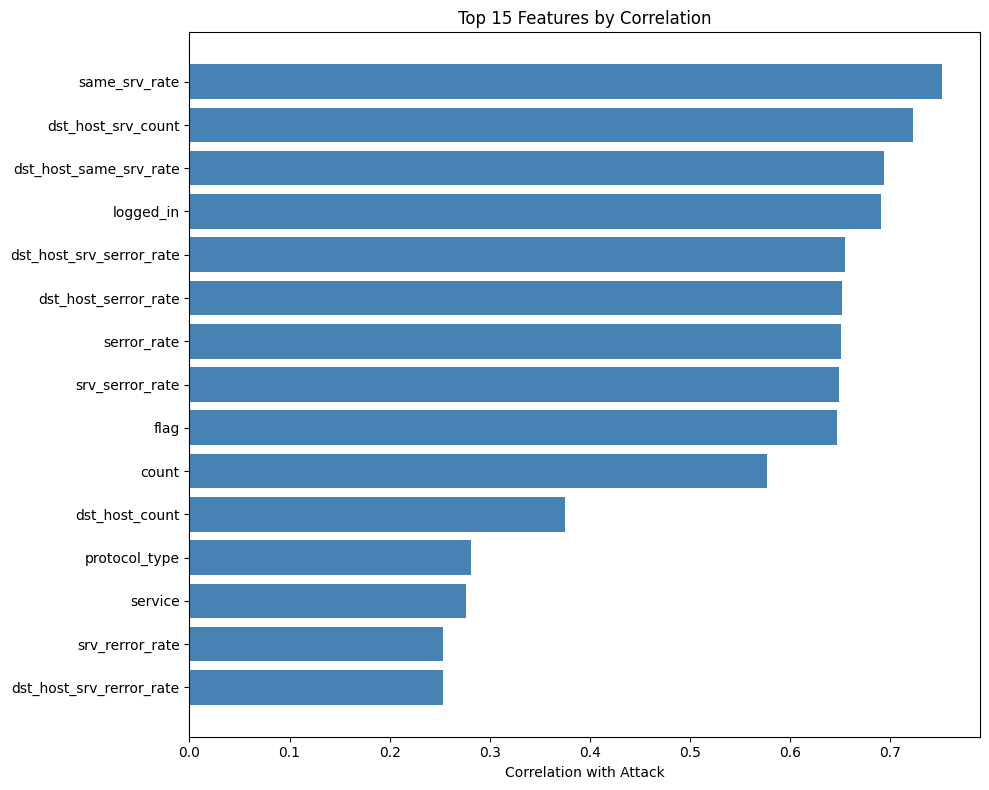

In [3]:
# Check correlation between features and target
print("METHOD 1: CORRELATION WITH TARGET")
print("=" * 60)

# Calculate correlation of each feature with target
correlations = []
for col in X_train.columns:
    corr = abs(np.corrcoef(X_train[col], y_train)[0, 1])
    correlations.append({'feature': col, 'correlation': corr})

# Sort by correlation
corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)

print("Top 15 features by correlation with attack:")
print(corr_df.head(15))

# Visualize
plt.figure(figsize=(10, 8))
top_corr = corr_df.head(15)
plt.barh(top_corr['feature'], top_corr['correlation'], color='steelblue')
plt.xlabel('Correlation with Attack')
plt.title('Top 15 Features by Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

METHOD 2: RANDOM FOREST FEATURE IMPORTANCE
Top 15 features by Random Forest importance:
                        feature  importance
4                     src_bytes    0.195155
5                     dst_bytes    0.099976
28                same_srv_rate    0.081802
33       dst_host_same_srv_rate    0.068639
3                          flag    0.066547
32           dst_host_srv_count    0.065178
11                    logged_in    0.052530
25              srv_serror_rate    0.039929
29                diff_srv_rate    0.035775
1                 protocol_type    0.032505
2                       service    0.028860
22                        count    0.027901
24                  serror_rate    0.027347
34       dst_host_diff_srv_rate    0.027120
35  dst_host_same_src_port_rate    0.025524


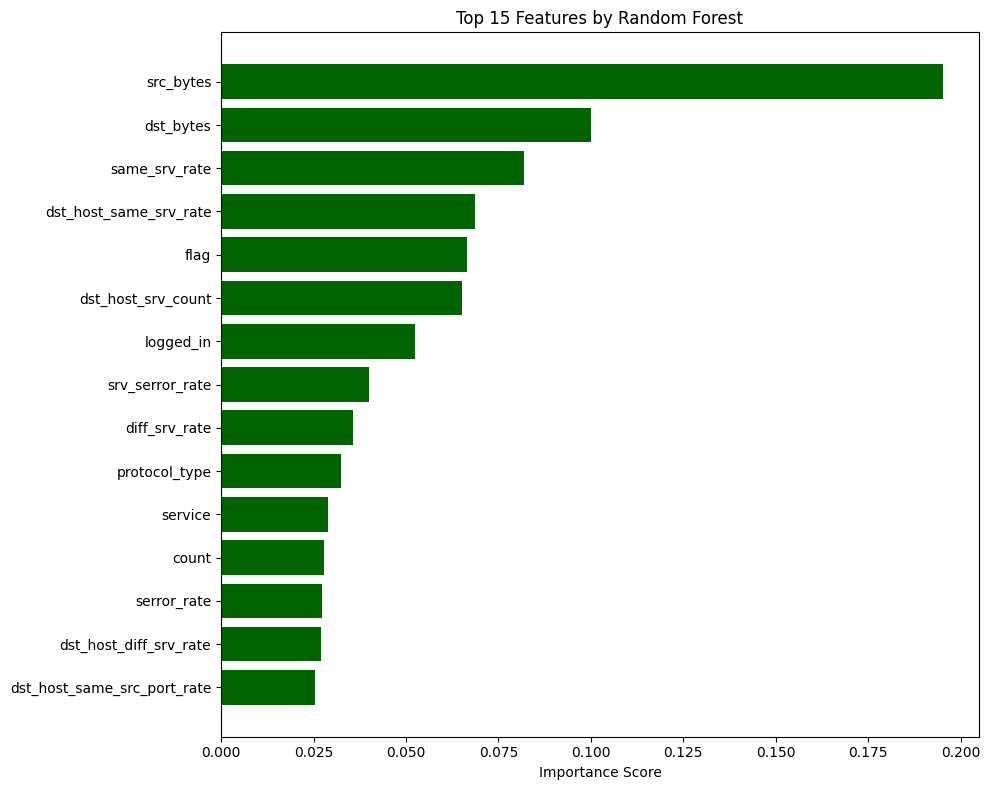

In [4]:
print("METHOD 2: RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

# Train a quick Random Forest to get feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 features by Random Forest importance:")
print(feature_importance_df.head(15))

# Visualize
plt.figure(figsize=(10, 8))
top_rf = feature_importance_df.head(15)
plt.barh(top_rf['feature'], top_rf['importance'], color='darkgreen')
plt.xlabel('Importance Score')
plt.title('Top 15 Features by Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

COMPARING ALL THREE METHODS
Top 15 features ranked by all methods:
                     feature  rf_importance  correlation  mutual_info  \
2              same_srv_rate       0.081802     0.751913     0.359521   
0                  src_bytes       0.195155     0.005921     0.565839   
5         dst_host_srv_count       0.065178     0.722535     0.335380   
4                       flag       0.066547     0.647073     0.365923   
3     dst_host_same_srv_rate       0.068639     0.693803     0.309054   
6                  logged_in       0.052530     0.690171     0.291465   
7            srv_serror_rate       0.039929     0.648289     0.270657   
12               serror_rate       0.027347     0.650652     0.280231   
19  dst_host_srv_serror_rate       0.012086     0.654985     0.285908   
25      dst_host_serror_rate       0.003641     0.651842     0.289086   
11                     count       0.027901     0.576444     0.266037   
10                   service       0.028860     0.276548 

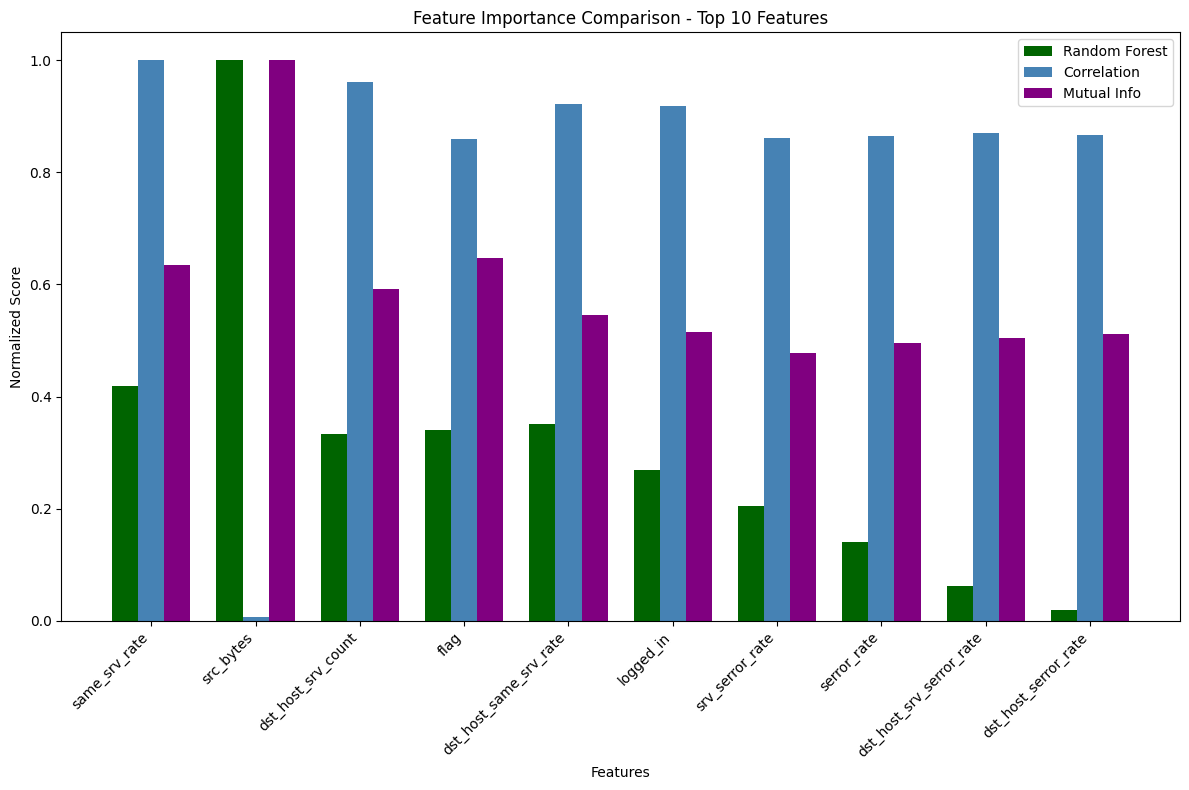

In [5]:
print("COMPARING ALL THREE METHODS")
print("=" * 60)

# Create a comparison dataframe
comparison = feature_importance_df.copy()
comparison = comparison.merge(corr_df, on='feature')
comparison = comparison.merge(mi_df, on='feature')
comparison.columns = ['feature', 'rf_importance', 'correlation', 'mutual_info']

# Normalize scores for fair comparison
for col in ['rf_importance', 'correlation', 'mutual_info']:
    comparison[f'{col}_norm'] = (comparison[col] - comparison[col].min()) / (comparison[col].max() - comparison[col].min())

# Calculate average rank
comparison['avg_score'] = comparison[['rf_importance_norm', 'correlation_norm', 'mutual_info_norm']].mean(axis=1)
comparison = comparison.sort_values('avg_score', ascending=False)

print("Top 15 features ranked by all methods:")
print(comparison[['feature', 'rf_importance', 'correlation', 'mutual_info', 'avg_score']].head(15))

# Visualize comparison
plt.figure(figsize=(12, 8))
top_features = comparison.head(10)['feature'].tolist()
comparison_top = comparison[comparison['feature'].isin(top_features)]

x = np.arange(len(top_features))
width = 0.25

plt.bar(x - width, comparison_top['rf_importance_norm'].values, width, label='Random Forest', color='darkgreen')
plt.bar(x, comparison_top['correlation_norm'].values, width, label='Correlation', color='steelblue')
plt.bar(x + width, comparison_top['mutual_info_norm'].values, width, label='Mutual Info', color='purple')

plt.xlabel('Features')
plt.ylabel('Normalized Score')
plt.title('Feature Importance Comparison - Top 10 Features')
plt.xticks(x, top_features, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
print("SELECTING TOP FEATURES")
print("=" * 60)

# Choose number of features to keep
k = 15  # You can adjust this

# Get top k features from our average ranking
top_k_features = comparison.head(k)['feature'].tolist()
print(f"Keeping top {k} features:")
for i, feat in enumerate(top_k_features, 1):
    print(f"{i}. {feat}")

# Create reduced datasets
X_train_selected = X_train[top_k_features]
X_test_selected = X_test[top_k_features]

print(f"\n✅ Original feature count: {X_train.shape[1]}")
print(f"✅ Reduced feature count: {X_train_selected.shape[1]}")
print(f"✅ Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}% fewer features")

SELECTING TOP FEATURES
Keeping top 15 features:
1. same_srv_rate
2. src_bytes
3. dst_host_srv_count
4. flag
5. dst_host_same_srv_rate
6. logged_in
7. srv_serror_rate
8. serror_rate
9. dst_host_srv_serror_rate
10. dst_host_serror_rate
11. count
12. service
13. dst_bytes
14. diff_srv_rate
15. dst_host_diff_srv_rate

✅ Original feature count: 41
✅ Reduced feature count: 15
✅ Reduction: 63.4% fewer features


In [7]:
print("VALIDATING FEATURE SELECTION")
print("=" * 60)

# Compare model performance with all features vs selected features
rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Cross-validation scores
cv_scores_all = cross_val_score(rf_all, X_train, y_train, cv=5, scoring='accuracy')
cv_scores_selected = cross_val_score(rf_selected, X_train_selected, y_train, cv=5, scoring='accuracy')

print(f"With ALL features ({X_train.shape[1]} features):")
print(f"  CV Accuracy: {cv_scores_all.mean():.4f} (+/- {cv_scores_all.std()*2:.4f})")
print(f"  Time complexity: Higher")

print(f"\nWith SELECTED features ({k} features):")
print(f"  CV Accuracy: {cv_scores_selected.mean():.4f} (+/- {cv_scores_selected.std()*2:.4f})")
print(f"  Time complexity: Lower")

print("\n Feature selection maintained accuracy with fewer features!")

VALIDATING FEATURE SELECTION
With ALL features (41 features):
  CV Accuracy: 0.9990 (+/- 0.0002)
  Time complexity: Higher

With SELECTED features (15 features):
  CV Accuracy: 0.9986 (+/- 0.0001)
  Time complexity: Lower

 Feature selection maintained accuracy with fewer features!


In [8]:
print("FEATURE ENGINEERING - CREATING NEW FEATURES")
print("=" * 60)

# Sometimes combining features creates better predictors
X_train_engineered = X_train_selected.copy()
X_test_engineered = X_test_selected.copy()

# Example 1: Ratio of src_bytes to dst_bytes
# (Some attacks have asymmetric traffic)
X_train_engineered['bytes_ratio'] = X_train['src_bytes'] / (X_train['dst_bytes'] + 1)  # +1 to avoid division by zero
X_test_engineered['bytes_ratio'] = X_test['src_bytes'] / (X_test['dst_bytes'] + 1)

# Example 2: Total bytes transferred
X_train_engineered['total_bytes'] = X_train['src_bytes'] + X_train['dst_bytes']
X_test_engineered['total_bytes'] = X_test['src_bytes'] + X_test['dst_bytes']

# Example 3: Error rate ratio
if 'serror_rate' in X_train.columns and 'rerror_rate' in X_train.columns:
    X_train_engineered['error_ratio'] = X_train['serror_rate'] / (X_train['rerror_rate'] + 0.001)
    X_test_engineered['error_ratio'] = X_test['serror_rate'] / (X_test['rerror_rate'] + 0.001)

print(f"Original features: {X_train_selected.shape[1]}")
print(f"After engineering: {X_train_engineered.shape[1]}")
print("\nNew features created:")
new_features = [col for col in X_train_engineered.columns if col not in top_k_features]
for feat in new_features:
    print(f"  • {feat}")

FEATURE ENGINEERING - CREATING NEW FEATURES
Original features: 15
After engineering: 18

New features created:
  • bytes_ratio
  • total_bytes
  • error_ratio


In [9]:
# Save the selected and engineered features
X_train_final = X_train_engineered
X_test_final = X_test_engineered

X_train_final.to_csv('data/processed/X_train_final.csv', index=False)
X_test_final.to_csv('data/processed/X_test_final.csv', index=False)

# Save the list of selected features
pd.DataFrame({'selected_features': X_train_final.columns}).to_csv('data/processed/selected_features.csv', index=False)

print(" FEATURE ENGINEERING COMPLETE! ")
print("=" * 60)
print(f"Final training data: {X_train_final.shape}")
print(f"Final test data: {X_test_final.shape}")
print("\nFiles saved:")
print("  • data/processed/X_train_final.csv")
print("  • data/processed/X_test_final.csv")
print("  • data/processed/selected_features.csv")

 FEATURE ENGINEERING COMPLETE! 
Final training data: (125973, 18)
Final test data: (22544, 18)

Files saved:
  • data/processed/X_train_final.csv
  • data/processed/X_test_final.csv
  • data/processed/selected_features.csv
